# Chapter 28 — Signal Conditioning: From Bridge Output to Readable Data

*Companion notebook to Chapter 28 — Signal Conditioning: From Bridge Output to Readable Data.*

The Wheatstone bridge converts strain into voltage — but the voltage is tiny. A 350 Ω quarter-bridge gage at 1000 με, driven with 5 V excitation and a gage factor of 2.07, produces only about 2.6 mV of bridge output; even at a full scale of 5000 με the bridge delivers just ~12.9 mV. To fill an ADC's ±10 V input range, that full-scale signal must be amplified by a factor of roughly 1000. That amplification must be done without adding noise that masks the measurement, and without introducing phase errors that corrupt dynamic data.

Two complementary concerns dominate signal conditioning: **noise** and **bandwidth**. Higher amplifier gain magnifies both signal and noise equally, so the useful dynamic range is set by the amplifier's input-referred noise voltage and the measurement bandwidth. Low-pass filtering reduces noise but limits the highest frequency that can be measured — and the filter's phase response determines whether time-stamped multi-channel measurements can be accurately compared. This notebook quantifies both concerns with real numbers.

**This notebook demonstrates:**
1. Full-scale bridge output, amplified voltage, RMS noise floor, and SNR for a representative system
2. First-order low-pass filter frequency response (Bode magnitude and phase) with fc = 200 Hz

In [1]:
# Colab setup — uncomment to install dependencies:
# !pip install numpy matplotlib

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Figures are written here; the book includes them by this exact path/filename.
OUT_DIR = Path("../src/media/ch28")
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 12})

---
## 1 — Amplifier Gain, Noise Floor, and SNR

With a gain of 1000 and an input-referred noise density of 5 nV/√Hz, the RMS noise in a 1 kHz bandwidth is 5 × √1000 × 1000 ≈ 158 μV at the output — or about 0.06 με referred back to the gage input. The full-scale bridge output at 5000 με is 12.9 mV, which amplifies to 12.9 V. The resulting SNR of ~98 dB means the system can resolve about 1 part in 80,000 of full scale — excellent for most structural measurements.

The numbers show why bandwidth discipline matters. Doubling the bandwidth from 1 kHz to 2 kHz increases the noise by √2 (41%), degrading the noise floor from 0.06 με to 0.085 με. Increasing to 10 kHz raises the noise by √10 (216%), pushing the floor to 0.19 με. For low-frequency structural tests, setting the anti-aliasing filter to the minimum bandwidth that captures the signal of interest is not just good practice — it is the primary noise control mechanism available after the amplifier is chosen.

In [2]:
# --- Representative single-channel signal-conditioning budget ---
GAIN              = 1000       # instrumentation-amplifier gain (V/V)
NOISE_DENSITY     = 5.0e-9     # amplifier input-referred noise density (V/sqrt(Hz))
BANDWIDTH_HZ      = 1000.0     # measurement bandwidth (Hz)
V_EXCITATION      = 5.0        # bridge excitation voltage (V)
GAGE_FACTOR       = 2.07       # foil gage factor (dimensionless)
FULL_SCALE_STRAIN = 5000e-6    # full-scale strain (strain, i.e. 5000 microstrain)


def quarter_bridge_output(v_ex, gage_factor, strain):
    """Quarter-bridge output voltage (V) for a single active gage.

    Vout = (Vex / 4) * GF * strain  (Chapter 28, gain and dynamic range).
    """
    return v_ex * gage_factor * strain / 4


def strain_from_output(v_out, v_ex, gage_factor):
    """Invert the quarter-bridge relation: strain from bridge output voltage.

    strain = 4 * Vout / (GF * Vex)  (Chapter 28, offset and zero drift).
    """
    return 4 * v_out / (gage_factor * v_ex)


v_bridge_fs = quarter_bridge_output(V_EXCITATION, GAGE_FACTOR, FULL_SCALE_STRAIN)
v_out_fs    = GAIN * v_bridge_fs
v_noise_in  = NOISE_DENSITY * np.sqrt(BANDWIDTH_HZ)   # input-referred RMS noise (V)
v_noise_out = GAIN * v_noise_in                        # output RMS noise (V)
strain_noise = strain_from_output(v_noise_in, V_EXCITATION, GAGE_FACTOR)  # strain
snr_db = 20 * np.log10(v_out_fs / v_noise_out)

print(f"Bridge FS output:   {v_bridge_fs * 1e3:.3f} mV")
print(f"Amplified output:   {v_out_fs:.3f} V")
print(f"RMS noise:          {v_noise_out * 1e6:.2f} μV  ({strain_noise * 1e6:.3f} με)")
print(f"SNR:                {snr_db:.1f} dB")

Bridge FS output:   12.938 mV
Amplified output:   12.938 V
RMS noise:          158.11 μV  (0.061 με)
SNR:                98.3 dB


---
## 2 — Low-Pass Filter: Frequency and Phase Response

A first-order RC low-pass filter attenuates signals above the cutoff frequency f_c at −20 dB per decade (−6 dB per octave). At f_c itself, the attenuation is exactly −3 dB — meaning the signal amplitude is reduced to 70.7% of its low-frequency value. This −3 dB point is the conventional definition of the filter bandwidth.

The phase response is equally important for dynamic strain measurements. At f_c, the filter introduces exactly −45° of phase shift. At 10·f_c, the phase approaches −90°. In a multi-channel system where all channels share the same filter, phase shifts are correlated and cancel in relative measurements. But when comparing channels with different filter settings, or when absolute timing matters (structural modal analysis, for example), the phase lag must be accounted for explicitly in post-processing.

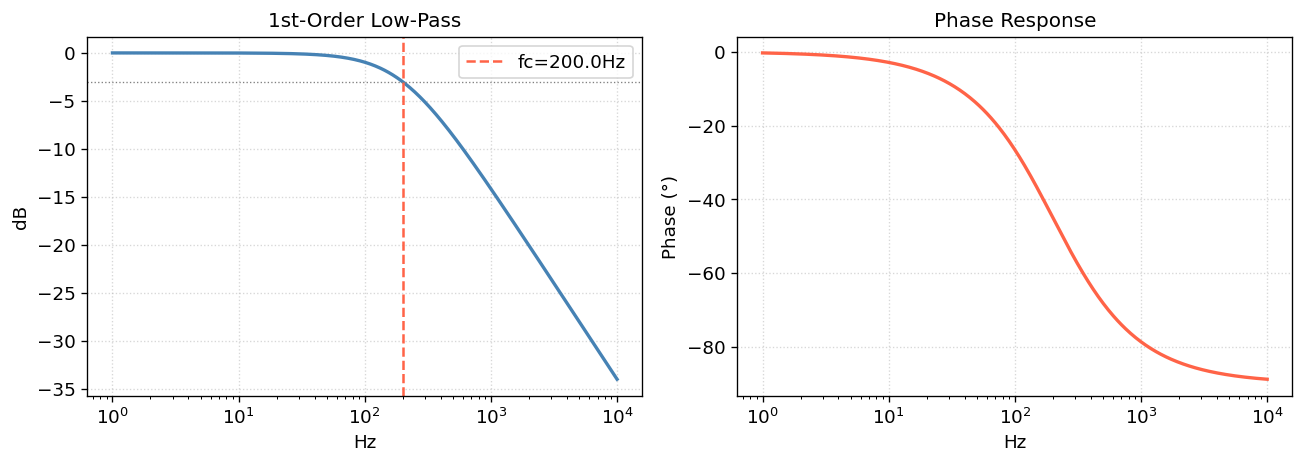

In [3]:
# First-order RC low-pass filter: magnitude and phase response
FC_HZ = 200.0   # example cutoff frequency (Hz)


def first_order_lowpass(freq_hz, fc_hz):
    """Magnitude (dB) and phase (degrees) of a first-order RC low-pass filter.

    |H| = 1 / sqrt(1 + (f/fc)^2)  ->  20*log10|H| = -10*log10(1 + (f/fc)^2)
    phase = -atan(f/fc)
    """
    ratio = freq_hz / fc_hz
    mag_db = -10 * np.log10(1 + ratio**2)
    phase_deg = -np.degrees(np.arctan(ratio))
    return mag_db, phase_deg


freq = np.logspace(0, 4, 500)
mag_db, phase_deg = first_order_lowpass(freq, FC_HZ)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogx(freq, mag_db, 'steelblue', lw=2)
axes[0].axvline(FC_HZ, color='tomato', lw=1.5, linestyle='--', label=f'fc={FC_HZ}Hz')
axes[0].axhline(-3, color='gray', lw=0.8, linestyle=':')
axes[0].set_xlabel('Hz'); axes[0].set_ylabel('dB'); axes[0].legend()
axes[0].set_title('1st-Order Low-Pass'); axes[0].grid(True, linestyle=':', alpha=0.5)
axes[1].semilogx(freq, phase_deg, 'tomato', lw=2)
axes[1].set_xlabel('Hz'); axes[1].set_ylabel('Phase (°)'); axes[1].set_title('Phase Response')
axes[1].grid(True, linestyle=':', alpha=0.5)
plt.tight_layout(); plt.savefig(OUT_DIR / 'fig28_nb1_lowpass_filter_response.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 3 — Choosing a Real Anti-Aliasing Filter

The single-pole response above rolls off at only −20 dB/decade, which is nowhere near steep enough to protect a converter. A real anti-aliasing filter has to do a specific job: everything above the **Nyquist frequency** (half the sample rate) must be attenuated enough that whatever folds back down into the measurement band is buried below the noise floor — a target of −60 dB is representative.

That requirement is what sets the cutoff frequency, and it explains why the cutoff sits so far below Nyquist rather than just underneath it. The plot below takes a 10 kSa/s system (Nyquist = 5 kHz) and compares three candidates against that target. Note that these are **analog** filters — an anti-aliasing filter must act before the converter, so it cannot be done in software.

Read the plot as three bands. The **passband** must be flat where the signal lives; the conventional −3 dB cutoff already costs 29% of amplitude, so the usable flat region ends well before it (Chapter 32). The **transition band** is wasted spectrum — sampled, but neither usable signal nor safely rejected. The **stopband** beyond Nyquist is the only part that actually prevents aliasing.

The results make the trade concrete:

| Filter | Cutoff | Attenuation at Nyquist |
|---|---|---|
| 1st-order RC | 1.0 kHz | −14 dB — useless for this purpose |
| 4-pole Butterworth | 1.0 kHz | −56 dB — close, but short of target |
| 8-pole Chebyshev (0.5 dB ripple) | 2.5 kHz | −76 dB — comfortably meets it |

The Chebyshev places its cutoff **2.5× higher** than the Butterworth and *still* rejects more at Nyquist. That extra usable bandwidth is bought with passband ripple and markedly worse phase linearity — which is why Butterworth remains the default when waveform fidelity or inter-channel timing matters, and Chebyshev wins when bandwidth is scarce. The RC filter cannot meet the target at any cutoff that leaves usable passband, which is the whole reason multi-pole active filters exist in signal conditioners.

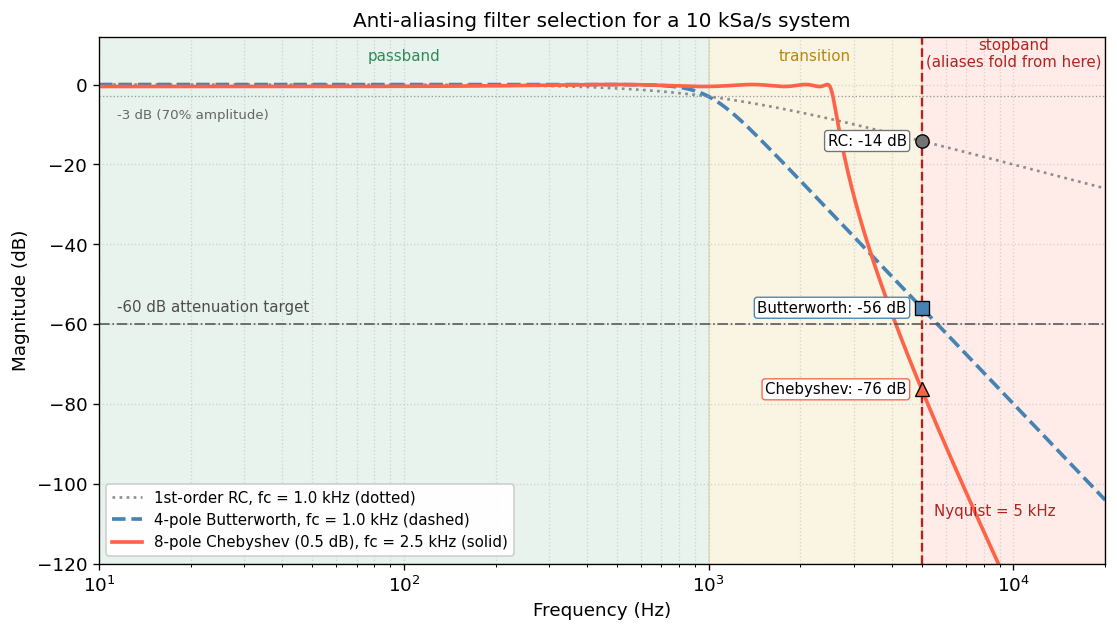

1st-order RC         fc=1.0 kHz  ->    -14.1 dB at Nyquist (short of the -60 dB target)
4-pole Butterworth   fc=1.0 kHz  ->    -55.9 dB at Nyquist (short of the -60 dB target)
8-pole Chebyshev     fc=2.5 kHz  ->    -76.4 dB at Nyquist (meets the -60 dB target)


In [4]:
# Anti-aliasing filter selection for a 10 kSa/s system.
# These are ANALOG filters by necessity -- an anti-aliasing filter must act
# before the converter, so the designs below use analog prototypes and are
# evaluated with signal.freqs (not freqz, whose response at Nyquist is an
# artifact of the digital sample rate rather than a physical attenuation).
from scipy import signal

SAMPLE_RATE_HZ = 10_000.0
NYQUIST_HZ     = SAMPLE_RATE_HZ / 2          # 5 kHz -- nothing above this may survive
STOPBAND_TARGET_DB = -60.0                   # desired attenuation at Nyquist

FC_RC_HZ     = 1_000.0  # 1st-order RC cutoff
FC_BUTTER_HZ = 1_000.0  # 4-pole Butterworth cutoff
FC_CHEBY_HZ  = 2_500.0  # 8-pole Chebyshev cutoff
CHEBY_RIPPLE_DB = 0.5   # passband ripple allowed by the Chebyshev design

freq = np.logspace(1, np.log10(SAMPLE_RATE_HZ * 2), 800)   # 10 Hz .. 20 kHz
w_rad = 2 * np.pi * freq


def analog_response_db(b, a, w):
    """Magnitude response in dB of an analog filter at angular frequencies w."""
    _, h = signal.freqs(b, a, worN=w)
    return 20 * np.log10(np.maximum(np.abs(h), 1e-14))


# 1st-order RC, analytic (matches Section 2)
rc_db = -10 * np.log10(1 + (freq / FC_RC_HZ) ** 2)

# Analog prototypes: Wn is in rad/s
b_bw, a_bw = signal.butter(4, 2 * np.pi * FC_BUTTER_HZ, btype='low', analog=True)
b_cb, a_cb = signal.cheby1(8, CHEBY_RIPPLE_DB, 2 * np.pi * FC_CHEBY_HZ,
                           btype='low', analog=True)
bw_db = analog_response_db(b_bw, a_bw, w_rad)
cb_db = analog_response_db(b_cb, a_cb, w_rad)

fig, ax = plt.subplots(figsize=(9.5, 5.4))

# Band shading: passband / transition / stopband
ax.axvspan(freq[0], FC_BUTTER_HZ, color='seagreen', alpha=0.10)
ax.axvspan(FC_BUTTER_HZ, NYQUIST_HZ, color='goldenrod', alpha=0.12)
ax.axvspan(NYQUIST_HZ, freq[-1], color='tomato', alpha=0.12)
ax.text(np.sqrt(freq[0] * FC_BUTTER_HZ), 6, 'passband', ha='center',
        fontsize=9, color='seagreen')
ax.text(np.sqrt(FC_BUTTER_HZ * NYQUIST_HZ), 6, 'transition', ha='center',
        fontsize=9, color='darkgoldenrod')
ax.text(np.sqrt(NYQUIST_HZ * freq[-1]), 4.5, 'stopband\n(aliases fold from here)',
        ha='center', fontsize=9, color='firebrick')

# Each design carries a non-color cue as well (line style + marker shape), so the
# curves stay distinct in the grayscale softcover edition: RC dotted/circle,
# Butterworth dashed/square, Chebyshev solid/triangle.
ax.semilogx(freq, rc_db, color='0.55', lw=1.6, ls=':',
            label=f'1st-order RC, fc = {FC_RC_HZ/1000:.1f} kHz (dotted)')
ax.semilogx(freq, bw_db, color='steelblue', lw=2.2, ls='--',
            label=f'4-pole Butterworth, fc = {FC_BUTTER_HZ/1000:.1f} kHz (dashed)')
ax.semilogx(freq, cb_db, color='tomato', lw=2.2, ls='-',
            label=f'8-pole Chebyshev (0.5 dB), fc = {FC_CHEBY_HZ/1000:.1f} kHz (solid)')

# Direct labels where the curves cross the Nyquist line, with matching marker shapes
for curve, colr, mk, short in ((rc_db, '0.45', 'o', 'RC'),
                               (bw_db, 'steelblue', 's', 'Butterworth'),
                               (cb_db, 'tomato', '^', 'Chebyshev')):
    y_nyq = np.interp(NYQUIST_HZ, freq, curve)
    ax.plot(NYQUIST_HZ, y_nyq, marker=mk, ms=8, color=colr, mec='black', mew=0.8,
            ls='none', zorder=5)
    ax.annotate(f'{short}: {y_nyq:.0f} dB', xy=(NYQUIST_HZ, y_nyq),
                xytext=(NYQUIST_HZ / 1.12, y_nyq), ha='right', va='center',
                fontsize=9, color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=colr, lw=0.8))

ax.axvline(NYQUIST_HZ, color='firebrick', lw=1.4, ls='--')
ax.annotate(f'Nyquist = {NYQUIST_HZ/1000:.0f} kHz', xy=(NYQUIST_HZ, -108),
            xytext=(NYQUIST_HZ * 1.1, -108), fontsize=9, color='firebrick')
ax.axhline(STOPBAND_TARGET_DB, color='0.35', lw=1.0, ls='-.')
ax.text(freq[0] * 1.15, STOPBAND_TARGET_DB + 3,
        f'{STOPBAND_TARGET_DB:.0f} dB attenuation target', fontsize=9, color='0.3')
ax.axhline(-3, color='0.6', lw=0.8, ls=':')
ax.text(freq[0] * 1.15, -8.5, '-3 dB (70% amplitude)', fontsize=8, color='0.4')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude (dB)')
ax.set_title(f'Anti-aliasing filter selection for a {SAMPLE_RATE_HZ/1000:.0f} kSa/s system')
ax.set_ylim(-120, 12)
ax.set_xlim(freq[0], freq[-1])
ax.grid(True, which='both', ls=':', alpha=0.45)
ax.legend(loc='lower left', fontsize=9, framealpha=0.92)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig28_nb2_antialiasing_selection.png', bbox_inches='tight', dpi=300)
plt.show()

# What each design actually delivers where it matters, and what it costs
for name, curve, fc in (('1st-order RC', rc_db, FC_RC_HZ),
                        ('4-pole Butterworth', bw_db, FC_BUTTER_HZ),
                        ('8-pole Chebyshev', cb_db, FC_CHEBY_HZ)):
    at_nyq = np.interp(NYQUIST_HZ, freq, curve)
    verdict = 'meets' if at_nyq <= STOPBAND_TARGET_DB else 'short of'
    print(f'{name:20s} fc={fc/1000:.1f} kHz  ->  {at_nyq:7.1f} dB at Nyquist '
          f'({verdict} the {STOPBAND_TARGET_DB:.0f} dB target)')

---
## Where to take this next

The two calculations above are deliberately minimal so you can extend them into a working design tool:

1. **From a first-order filter to a real anti-aliasing filter.** The single-pole RC response here rolls off at only −20 dB/decade — far too gentle to protect a converter. Use `scipy.signal.butter` and `freqz` to plot a 4-pole Butterworth against the RC curve, then check how much stopband attenuation each provides at the Nyquist frequency for a chosen sample rate (say 10 kSa/s). This turns the "cutoff at one-fifth to one-tenth of the sample rate" guideline from the chapter into a number you can defend.

2. **Excitation vs. self-heating trade-off.** Sweep `V_EXCITATION` from 1 V to 10 V and plot two curves on the same axis: SNR (which improves with excitation) and gage power dissipation `P = Vex**2 / (4 * R_gage)` from Eq. 28.1 (which grows as the square of excitation). The crossover, read against the manufacturer's allowable power density, is exactly the excitation-selection decision the chapter describes.

3. **Phase linearity across channels.** Add a Bessel filter (`scipy.signal.bessel`) and compare its group delay to the Butterworth and the RC filter. Feed a synthetic multi-tone strain burst through each and inspect the waveform distortion — this makes concrete why Bessel is preferred when absolute timing between channels matters in modal analysis.